In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nishan192/letterrecognition-using-svm")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'letterrecognition-using-svm' dataset.
Path to dataset files: /kaggle/input/letterrecognition-using-svm


In [ ]:
df = pd.read_csv("/kaggle/input/letterrecognition-using-svm/letter-recognition.csv")

In [ ]:
print("\nFirst 5 rows:\n", df.head())
print("\nDataset Info:\n")
print(df.info())
print("\nStatistical Summary:\n", df.describe())
print("\nMissing Values:\n", df.isnull().sum())


First 5 rows:
   letter  xbox   ybox   width   height  onpix   xbar   ybar   x2bar  y2bar   \
0      T      2      8       3       5       1      8     13      0       6   
1      I      5     12       3       7       2     10      5      5       4   
2      D      4     11       6       8       6     10      6      2       6   
3      N      7     11       6       6       3      5      9      4       6   
4      G      2      1       3       1       1      8      6      6       6   

   xybar   x2ybar  xy2bar  xedge   xedgey  yedge   yedgex  
0       6      10       8       0       8       0       8  
1      13       3       9       2       8       4      10  
2      10       3       7       3       7       3       9  
3       4       4      10       6      10       2       8  
4       6       5       9       1       7       5      10  

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 17 columns):
 #   Column  Non-Null Co

In [ ]:
X = df.drop('letter', axis=1)
y = df['letter']

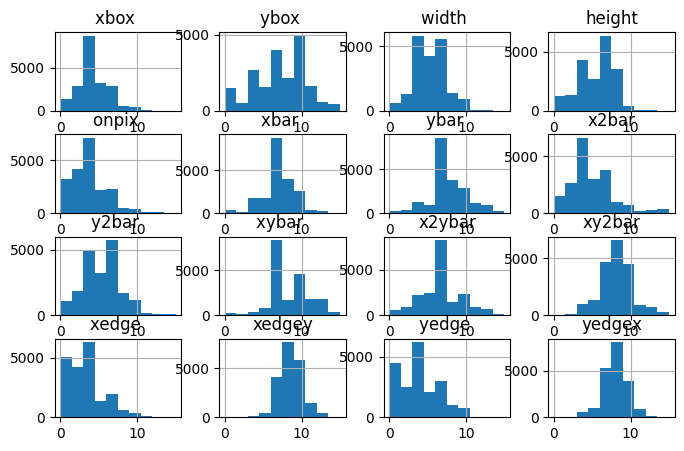

In [ ]:
df.hist(figsize=(8,5))
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
svm = SVC(kernel='rbf', random_state=42)   # RBF kernel (default)
svm.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [ ]:
y_pred = svm.predict(X_test_scaled)

In [ ]:
acc = accuracy_score(y_test, y_pred)
print("\nSVM Accuracy:", acc)


SVM Accuracy: 0.9443333333333334


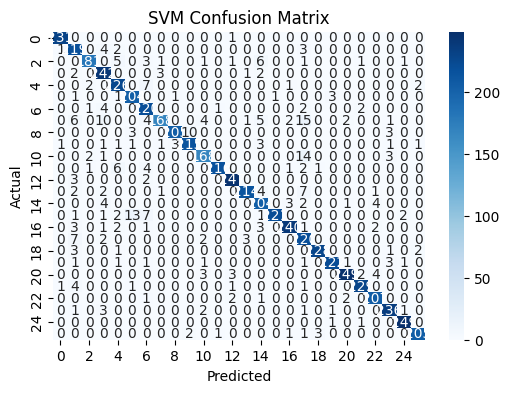

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap='Blues', fmt='d')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           A       0.99      1.00      0.99       232
           B       0.87      0.96      0.91       229
           C       0.97      0.90      0.93       201
           D       0.88      0.97      0.92       250
           E       0.91      0.95      0.93       238
           F       0.92      0.97      0.94       211
           G       0.88      0.96      0.92       230
           H       0.97      0.77      0.86       218
           I       0.98      0.93      0.95       221
           J       0.95      0.94      0.95       228
           K       0.93      0.89      0.91       188
           L       0.99      0.94      0.96       231
           M       0.97      0.98      0.97       252
           N       0.98      0.93      0.95       231
           O       0.89      0.94      0.91       218
           P       1.00      0.89      0.94       248
           Q       0.97      0.95      0.96       253
  